In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest

In [4]:
features = [
    "power",
    "voltage",
    "current",
    "frequency",
    "powerFactor",
    "temperature",
    "occupancyLevel"
]

In [5]:
df = pd.read_csv("campusvolt_energy_data.csv")

In [6]:
X = df[features]

In [7]:
model = IsolationForest(
    contamination=0.05,
    random_state=42
)

In [8]:
model.fit(X)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [9]:
anomaly_prediction = model.predict(X)
print(anomaly_prediction)

[1 1 1 ... 1 1 1]


In [10]:
arr = np.array(anomaly_prediction)

In [11]:
pd.Series(arr).unique()

array([ 1, -1])

In [12]:
pd.Series(anomaly_prediction).value_counts()

 1    41610
-1     2190
Name: count, dtype: int64

In [13]:
df["Anomaly"] = anomaly_prediction

In [14]:
df.head()

,timestamp,meterId,buildingId,buildingName,voltage,current,power,energy,frequency,powerFactor,temperature,occupancyLevel,weatherCondition,dayType,workingHours,scenario,status,simulationTime,simulationSpeed,Anomaly
0,2025-01-01 00:00:00,M001,B001,Academic Block,232.30,53.68,19.37,19.37,49.962,0.891,19.82,6.59,Sunny,Weekday,False,Normal,Normal,2025-01-01 00:00:00,1,1
1,2025-01-01 01:00:00,M001,B001,Academic Block,226.96,44.72,15.56,34.93,50.025,0.866,20.73,0.00,Sunny,Weekday,False,Normal,Normal,2025-01-01 01:00:00,1,1
2,2025-01-01 02:00:00,M001,B001,Academic Block,230.33,33.41,11.96,46.89,49.908,0.889,20.94,7.99,Sunny,Weekday,False,Normal,Normal,2025-01-01 02:00:00,1,1
3,2025-01-01 03:00:00,M001,B001,Academic Block,232.47,31.70,11.61,58.50,49.902,0.883,19.98,0.00,Cloudy,Weekday,False,Normal,Normal,2025-01-01 03:00:00,1,1
4,2025-01-01 04:00:00,M001,B001,Academic Block,229.10,38.65,13.48,71.98,49.882,0.873,21.42,9.41,Cloudy,Weekday,False,Normal,Normal,2025-01-01 04:00:00,1,1


In [15]:
anomalies = df[df["Anomaly"] == -1]
anomalies.head()

,timestamp,meterId,buildingId,buildingName,voltage,current,power,energy,frequency,powerFactor,temperature,occupancyLevel,weatherCondition,dayType,workingHours,scenario,status,simulationTime,simulationSpeed,Anomaly
62,2025-01-03 14:00:00,M001,B001,Academic Block,234.32,275.31,99.20,2927.62,49.802,0.896,27.95,68.68,Sunny,Weekday,True,Normal,Normal,2025-01-03 14:00:00,1,-1
133,2025-01-06 13:00:00,M001,B001,Academic Block,223.25,318.20,110.68,4493.18,49.945,0.915,28.45,84.56,Sunny,Weekday,True,Normal,Normal,2025-01-06 13:00:00,1,-1
209,2025-01-09 17:00:00,M001,B001,Academic Block,228.80,280.66,102.40,7889.10,49.948,0.895,19.86,89.22,Rainy,Weekday,True,Normal,Normal,2025-01-09 17:00:00,1,-1
226,2025-01-10 10:00:00,M001,B001,Academic Block,228.99,293.94,107.75,8391.18,50.033,0.940,26.36,95.00,Sunny,Weekday,True,Normal,Normal,2025-01-10 10:00:00,1,-1
300,2025-01-13 12:00:00,M001,B001,Academic Block,232.01,421.65,154.72,10231.11,50.112,0.923,27.35,92.98,Cloudy,Weekday,True,Equipment Fault,Warning,2025-01-13 12:00:00,1,-1


In [16]:
anomalies.head()

,timestamp,meterId,buildingId,buildingName,voltage,current,power,energy,frequency,powerFactor,temperature,occupancyLevel,weatherCondition,dayType,workingHours,scenario,status,simulationTime,simulationSpeed,Anomaly
62,2025-01-03 14:00:00,M001,B001,Academic Block,234.32,275.31,99.20,2927.62,49.802,0.896,27.95,68.68,Sunny,Weekday,True,Normal,Normal,2025-01-03 14:00:00,1,-1
133,2025-01-06 13:00:00,M001,B001,Academic Block,223.25,318.20,110.68,4493.18,49.945,0.915,28.45,84.56,Sunny,Weekday,True,Normal,Normal,2025-01-06 13:00:00,1,-1
209,2025-01-09 17:00:00,M001,B001,Academic Block,228.80,280.66,102.40,7889.10,49.948,0.895,19.86,89.22,Rainy,Weekday,True,Normal,Normal,2025-01-09 17:00:00,1,-1
226,2025-01-10 10:00:00,M001,B001,Academic Block,228.99,293.94,107.75,8391.18,50.033,0.940,26.36,95.00,Sunny,Weekday,True,Normal,Normal,2025-01-10 10:00:00,1,-1
300,2025-01-13 12:00:00,M001,B001,Academic Block,232.01,421.65,154.72,10231.11,50.112,0.923,27.35,92.98,Cloudy,Weekday,True,Equipment Fault,Warning,2025-01-13 12:00:00,1,-1


In [17]:
normal = df[df["Anomaly"]==1]

In [18]:
normal.head()

,timestamp,meterId,buildingId,buildingName,voltage,current,power,energy,frequency,powerFactor,temperature,occupancyLevel,weatherCondition,dayType,workingHours,scenario,status,simulationTime,simulationSpeed,Anomaly
0,2025-01-01 00:00:00,M001,B001,Academic Block,232.30,53.68,19.37,19.37,49.962,0.891,19.82,6.59,Sunny,Weekday,False,Normal,Normal,2025-01-01 00:00:00,1,1
1,2025-01-01 01:00:00,M001,B001,Academic Block,226.96,44.72,15.56,34.93,50.025,0.866,20.73,0.00,Sunny,Weekday,False,Normal,Normal,2025-01-01 01:00:00,1,1
2,2025-01-01 02:00:00,M001,B001,Academic Block,230.33,33.41,11.96,46.89,49.908,0.889,20.94,7.99,Sunny,Weekday,False,Normal,Normal,2025-01-01 02:00:00,1,1
3,2025-01-01 03:00:00,M001,B001,Academic Block,232.47,31.70,11.61,58.50,49.902,0.883,19.98,0.00,Cloudy,Weekday,False,Normal,Normal,2025-01-01 03:00:00,1,1
4,2025-01-01 04:00:00,M001,B001,Academic Block,229.10,38.65,13.48,71.98,49.882,0.873,21.42,9.41,Cloudy,Weekday,False,Normal,Normal,2025-01-01 04:00:00,1,1


In [19]:
normal[features].mean()

power              41.120459
voltage           230.051734
current           115.767957
frequency          50.000282
powerFactor         0.887127
temperature        30.239082
occupancyLevel     27.922634
dtype: float64

In [20]:
anomalies[features].mean()

power             112.494406
voltage           229.340187
current           314.760840
frequency          49.994110
powerFactor         0.899426
temperature        34.479758
occupancyLevel     67.284219
dtype: float64

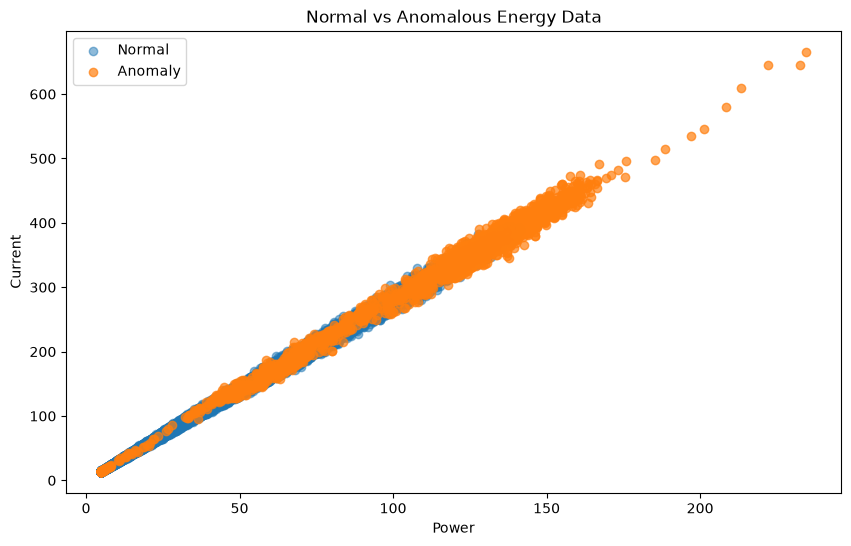

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    normal["power"],
    normal["current"],
    label="Normal",
    alpha=0.5
)

plt.scatter(
    anomalies["power"],
    anomalies["current"],
    label="Anomaly",
    alpha=0.7
)

plt.xlabel("Power")
plt.ylabel("Current")
plt.title("Normal vs Anomalous Energy Data")
plt.legend()

plt.show()